<a href="https://colab.research.google.com/github/DinhThanh-Dat/ThucHanhDeepLearning/blob/main/Baitaptuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#2. CÀI ĐẶT MÔ HÌNH AUTOENCODER

Phần này sẽ trình bày cài đặt mô hình autoencoder cho bài toán phân lớp trên bộ dataset Fashion_mnist.  

##2.1. Nạp thư viện

In [ ]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

##2.2. Nạp dataset

In [ ]:
# Tải bộ dữ liệu MNIST và chia thành 2 phần: tập huấn luyện (train) và tập kiểm tra (test)
# Vì đây là mô hình Autoencoder (học không giám sát) nên chúng ta bỏ qua nhãn kết quả (_)
(x_train, _), (x_test, _) = mnist.load_data()
# Chuẩn hóa dữ liệu ảnh: Ép kiểu sang số thực float32 và chia cho 255.0 để đưa dải pixel từ [0, 255] về đoạn [0, 1]
x_train = x_train.astype('float32') / 225.
x_test = x_test.astype('float32') / 225.

# Duỗi phẳng (reshape) ma trận ảnh hai chiều kích thước 28x28 thành một mảng phẳng một chiều gồm 784 phần tử
# Kích thước mới của tập dữ liệu: Tập train là (60000, 784), Tập test là (10000, 784)
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


##2.3. Xây dựng mô hình Autoencoder

In [ ]:
# Đây là kích thước của biểu diễn đã được mã hóa (encoded)
encoding_dim = 32  # 32 số thực -> tỷ lệ nén 24.5 lần, giả sử đầu vào gồm 784 số thực

# Đây là ảnh đầu vào của chúng ta
input_img = keras.Input(shape=(784,))

# "encoded" là biểu diễn đã được mã hóa của dữ liệu đầu vào
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)

# "decoded" là bản tái tạo (khôi phục có mất mát dữ liệu) của đầu vào
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# Mô hình này ánh xạ dữ liệu đầu vào sang dữ liệu được tái tạo
autoencoder = keras.Model(input_img, decoded)

# Mô hình này ánh xạ dữ liệu đầu vào sang biểu diễn đã được mã hóa
encoder = keras.Model(input_img, encoded)

# Đây là đầu vào đã được mã hóa của chúng ta (32 chiều)
encoded_input = keras.Input(shape=(encoding_dim,))

# Lấy lớp cuối cùng của mô hình autoencoder
decoder_layer = autoencoder.layers[-1]

# Lấy lớp cuối cùng của mô hình autoencoder
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

##2.4. Huấn luyện mô hình

In [ ]:
# Thiết lập quá trình huấn luyện: sử dụng thuật toán tối ưu 'adam' và hàm mất mát sai số nhị phân 'binary_crossentropy'
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, verbose=1, shuffle=True, validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.0085 - loss: 0.2675 - val_accuracy: 0.0092 - val_loss: 0.1695
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0112 - loss: 0.1459 - val_accuracy: 0.0120 - val_loss: 0.1219
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.0111 - loss: 0.1113 - val_accuracy: 0.0114 - val_loss: 0.0965
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0109 - loss: 0.0906 - val_accuracy: 0.0092 - val_loss: 0.0791
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0108 - loss: 0.0761 - val_accuracy: 0.0118 - val_loss: 0.0662
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0134 - loss: 0.0651 - val_accuracy: 0.0138 - val_loss: 0.0562
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0168 - loss: 0.0563 - val_accuracy: 0.0162 - val_loss: 0.0482
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0188 - loss: 0.0490 - val_accu

##2.5. Dự báo loại ảnh sử dụng Autoencoder

In [ ]:
# Sử dụng mô hình encoder để nén toàn bộ tập ảnh x_test sang dạng không gian ẩn 32 chiều
encoded_imgs = encoder.predict(x_test)
# Sử dụng mô hình decoder để giải nén từ không gian ẩn 32 chiều về lại ảnh gốc 784 chiều
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


##2.6. Hiển thị ảnh từ mô hình Autoencoder

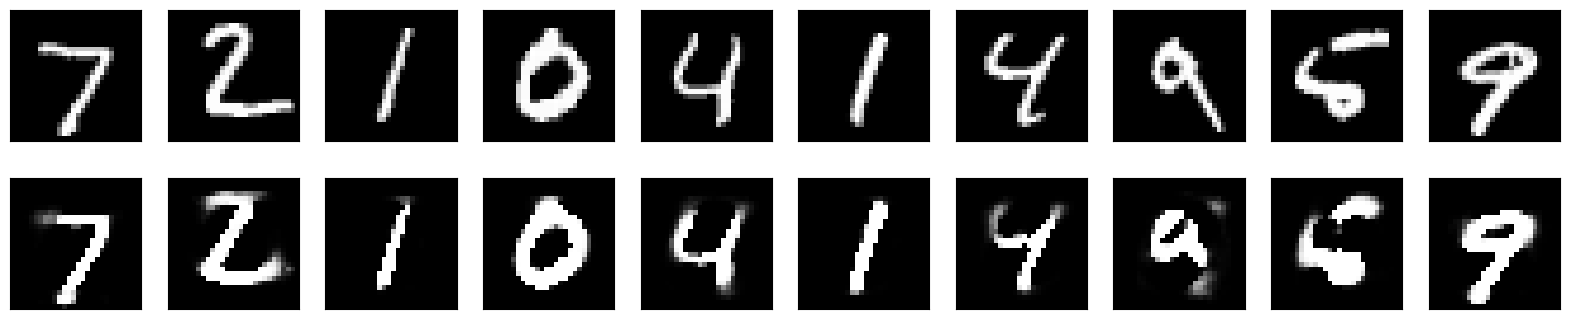

In [ ]:
import matplotlib.pyplot as plt

n =10 #số lượng hình ảnh muốn hiển thị

plt.figure(figsize=(20,4)) #khởi tạo khung vẽ lớn có kích thước 20 inch cao 4 inch
for i in range(n):
    # hiển thị ảnh gốc
    ax = plt.subplot(2, n, i+1) # tạo 1 ô vẽ nằm ở dòng 1, cột thứ i+1

    # Định hình lại mảng phẳng 784 phần tử về ma trận ảnh 2 chiều 28x28 và vẽ dưới dạng ảnh
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()

    #ẩn các vạch chia tọa độ trên trục X và trục Y để ảnh sạch đẹp hơn
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    #hiển thị ảnh ảnh sau khi dự báo tái tạo
    ax = plt.subplot(2, n, i+1+n) #tạo ô vẽ nhỏ nằm ở dòng 2, cột i+1

    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()

    #ẩn hoàn toàn các trục tọa độ X và Y của ảnh tái tạo
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

#3. CẢI TIẾN AUTOENCODER

##3.1. Thêm L1

Ta chỉ mới ràng buộc kích thước tầng ẩn là 32, tuy nhiên kết quả học của mô hình chưa thật sự rõ như
input data. Ta có thể cải tiến bằng cách thêm L1 như sau

In [ ]:
from keras import regularizers
# Đây là kích thước của các biểu diễn đã được mã hóa
encoding_dim = 32  # 32 số thực -> hệ số nén 24.5 lần, giả sử đầu vào gồm 784 số thực

# Đây là ảnh đầu vào của chúng ta
input_img = keras.Input(shape=(784,))

# "encoded" là biểu diễn đã được mã hóa của dữ liệu đầu vào
encoded = layers.Dense(encoding_dim, activity_regularizer=regularizers.l1(10e-5), activation='relu')(input_img)

# "decoded" là dữ liệu đầu vào được tái tạo lại (có mất mát thông tin)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# Mô hình này ánh xạ dữ liệu đầu vào sang dữ liệu được tái tạo
autoencoder = keras.Model(input_img, decoded)

# Mô hình này ánh xạ dữ liệu đầu vào sang biểu diễn đã được mã hóa
encoder = keras.Model(input_img, encoded)

# Đây là đầu vào đã được mã hóa của chúng ta (32 chiều)
encoded_input = keras.Input(shape=(encoding_dim,))

# Lấy lớp cuối cùng của mô hình autoencoder
decoder_layer = autoencoder.layers[-1]

# Tạo mô hình decoder (bộ giải mã)
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
# Biên dịch mô hình với bộ tối ưu Adam và hàm mất mát Binary Crossentropy
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Huấn luyện mô hình Autoencoder
# Đầu vào và đầu ra đều là x_train (tự tái tạo dữ liệu)
autoencoder.fit(x_train,x_train,epochs=100,batch_size=256, verbose=1, shuffle=True,validation_data=(x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.0140 - loss: 0.6564 - val_accuracy: 0.0161 - val_loss: 0.6179
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0150 - loss: 0.5868 - val_accuracy: 0.0161 - val_loss: 0.5578
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0150 - loss: 0.5328 - val_accuracy: 0.0161 - val_loss: 0.5095
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.4893 - val_accuracy: 0.0161 - val_loss: 0.4705
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.4542 - val_accuracy: 0.0161 - val_loss: 0.4389
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0150 - loss: 0.4256 - val_accuracy: 0.0161 - val_loss: 0.4131
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0150 - loss: 0.4023 - val_accuracy: 0.0161 - val_loss: 0.3920
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0150 - loss: 0.3832 - 

##3.2. Thêm layers

In [ ]:
# Đây là kích thước của biểu diễn đã được mã hóa
encoding_dim =32   #32 số thực -> tỷ lệ nén 24.5 lần, giả sử đầu vào gồm 784 số thực

# Phương pháp 2: Tăng số lượng tầng ẩn

# Đây là ảnh đầu vào của chúng ta
input_img = keras.Input(shape=(784,))

# "encoded" là biểu diễn đã được mã hóa của dữ liệu đầu vào
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# "decoded" là dữ liệu được tái tạo lại từ đầu vào
decocded = layers.Dense(784, activation='sigmoid')(encoded)

# Mô hình này ánh xạ dữ liệu đầu vào sang dữ liệu được tái tạo
autoencoder = keras.Model(input_img, decoded)

# Mô hình này ánh xạ dữ liệu đầu vào sang biểu diễn đã được mã hóa
encoder = keras.Model(input_img, encoded)

# Đây là đầu vào đã được mã hóa của chúng ta (32 chiều)
encoded_input = keras.Input(shape=(32,))

# Lấy lớp cuối cùng của mô hình autoencoder
decoder_layer = autoencoder.layers[-1]

# Tạo mô hình decoder (bộ giải mã)
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))



#4. BÀI TẬP

###Viết chương trình cài đặt Autoencoder để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong
tensorflow với các nhãn sau


## 4.1. Nạp dataset CIFAR10

In [5]:
from keras.datasets import cifar10
import numpy as np

# Tải bộ dữ liệu CIFAR10 và chia thành tập huấn luyện và tập kiểm tra
(x_train_cifar, _), (x_test_cifar, _) = cifar10.load_data()

# Chuẩn hóa dữ liệu ảnh: Ép kiểu sang số thực float32 và chia cho 255.0 để đưa dải pixel từ [0, 255] về đoạn [0, 1]
x_train_cifar = x_train_cifar.astype('float32') / 255.0
x_test_cifar = x_test_cifar.astype('float32') / 255.0

# Duỗi phẳng (reshape) ma trận ảnh ba chiều (32x32x3) thành một mảng phẳng một chiều gồm 3072 phần tử
x_train_cifar = x_train_cifar.reshape((len(x_train_cifar), np.prod(x_train_cifar.shape[1:])))
x_test_cifar = x_test_cifar.reshape((len(x_test_cifar), np.prod(x_test_cifar.shape[1:])))

print(x_train_cifar.shape)
print(x_test_cifar.shape)

(50000, 3072)
(10000, 3072)


## 4.2. Xây dựng mô hình Autoencoder cho CIFAR10

In [6]:
import keras
from keras import layers
from keras import models

# Kích thước của biểu diễn đã được mã hóa
encoding_dim_cifar = 128  # Chọn một kích thước mã hóa phù hợp cho CIFAR10 (32x32x3 = 3072 đầu vào)

# Đây là ảnh đầu vào của chúng ta (3072 chiều)
input_img_cifar = keras.Input(shape=(3072,))

# Encoder
encoded_cifar = layers.Dense(encoding_dim_cifar, activation='relu')(input_img_cifar)

# Decoder
decoded_cifar = layers.Dense(3072, activation='sigmoid')(encoded_cifar)

# Autoencoder model
autoencoder_cifar = keras.Model(input_img_cifar, decoded_cifar)

# Encoder model
encoder_cifar = keras.Model(input_img_cifar, encoded_cifar)

# Decoder model
encoded_input_cifar = keras.Input(shape=(encoding_dim_cifar,))
decoder_layer_cifar = autoencoder_cifar.layers[-1]
decoder_cifar = keras.Model(encoded_input_cifar, decoder_layer_cifar(encoded_input_cifar))

## 4.3. Huấn luyện mô hình Autoencoder cho CIFAR10

In [7]:
autoencoder_cifar.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder_cifar.fit(x_train_cifar, x_train_cifar, epochs=50, batch_size=256, verbose=1, shuffle=True, validation_data=(x_test_cifar, x_test_cifar))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.0020 - loss: 0.6384 - val_accuracy: 0.0038 - val_loss: 0.6178
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.0037 - loss: 0.6105 - val_accuracy: 0.0048 - val_loss: 0.6065
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.0046 - loss: 0.6028 - val_accuracy: 0.0056 - val_loss: 0.6006
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.0054 - loss: 0.5973 - val_accuracy: 0.0061 - val_loss: 0.5954
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.0061 - loss: 0.5926 - val_accuracy: 0.0062 - val_loss: 0.5908
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.0062 - loss: 0.5897 - val_accuracy: 0.0072 - val_loss: 0.5886
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.0056 - loss: 0.5871 - val_accuracy: 0.0075 - val_loss: 0.5865
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.0066 - loss: 0.5853 - val_acc

## 4.4. Hiển thị ảnh gốc và ảnh tái tạo từ mô hình Autoencoder CIFAR10

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


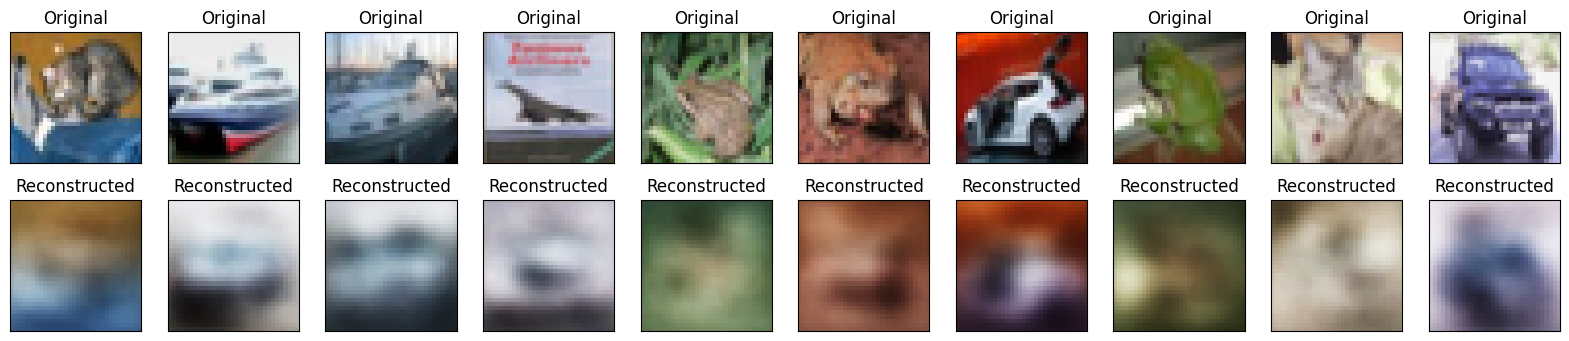

In [8]:
import matplotlib.pyplot as plt

# Sử dụng mô hình encoder để nén toàn bộ tập ảnh x_test_cifar
encoded_imgs_cifar = encoder_cifar.predict(x_test_cifar)
# Sử dụng mô hình decoder để giải nén từ không gian ẩn về lại ảnh gốc
decoded_imgs_cifar = decoder_cifar.predict(encoded_imgs_cifar)

n = 10  # Số lượng hình ảnh muốn hiển thị

plt.figure(figsize=(20, 4))
for i in range(n):
    # Hiển thị ảnh gốc
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cifar[i].reshape(32, 32, 3))
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Hiển thị ảnh sau khi dự báo tái tạo
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_cifar[i].reshape(32, 32, 3))
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

###bài 2. Hãy viết chương trình cài đặt Autoencoder để nhận dạng ảnh Cat hoặc Dog.

## 5. Nhận dạng ảnh Cat hoặc Dog với Autoencoder

### 5.1. Nạp và tiền xử lý dataset CIFAR10 (chỉ Cat và Dog)

In [9]:
from keras.datasets import cifar10
import numpy as np

# Tải bộ dữ liệu CIFAR10 (bao gồm cả nhãn)
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

# CIFAR10 labels:
# 0: airplane
# 1: automobile
# 2: bird
# 3: cat
# 4: deer
# 5: dog
# 6: frog
# 7: horse
# 8: ship
# 9: truck

# Lọc lấy ảnh mèo (label 3) và chó (label 5)
cat_dog_train_indices = np.where((y_train_full == 3) | (y_train_full == 5))[0]
cat_dog_test_indices = np.where((y_test_full == 3) | (y_test_full == 5))[0]

x_train_cat_dog = x_train_full[cat_dog_train_indices]
y_train_cat_dog = y_train_full[cat_dog_train_indices]
x_test_cat_dog = x_test_full[cat_dog_test_indices]
y_test_cat_dog = y_test_full[cat_dog_test_indices]

# Chuyển đổi nhãn: cat (3) thành 0, dog (5) thành 1
y_train_cat_dog[y_train_cat_dog == 3] = 0
y_train_cat_dog[y_train_cat_dog == 5] = 1
y_test_cat_dog[y_test_cat_dog == 3] = 0
y_test_cat_dog[y_test_cat_dog == 5] = 1

# Chuẩn hóa dữ liệu ảnh: Ép kiểu sang số thực float32 và chia cho 255.0 để đưa dải pixel từ [0, 255] về đoạn [0, 1]
x_train_cat_dog = x_train_cat_dog.astype('float32') / 255.0
x_test_cat_dog = x_test_cat_dog.astype('float32') / 255.0

# Duỗi phẳng (reshape) ma trận ảnh ba chiều (32x32x3) thành một mảng phẳng một chiều gồm 3072 phần tử
x_train_cat_dog_flat = x_train_cat_dog.reshape((len(x_train_cat_dog), np.prod(x_train_cat_dog.shape[1:])))
x_test_cat_dog_flat = x_test_cat_dog.reshape((len(x_test_cat_dog), np.prod(x_test_cat_dog.shape[1:])))

print("Shape of x_train_cat_dog_flat:", x_train_cat_dog_flat.shape)
print("Shape of y_train_cat_dog:", y_train_cat_dog.shape)
print("Shape of x_test_cat_dog_flat:", x_test_cat_dog_flat.shape)
print("Shape of y_test_cat_dog:", y_test_cat_dog.shape)

Shape of x_train_cat_dog_flat: (10000, 3072)
Shape of y_train_cat_dog: (10000, 1)
Shape of x_test_cat_dog_flat: (2000, 3072)
Shape of y_test_cat_dog: (2000, 1)


### 5.2. Xây dựng và huấn luyện mô hình Autoencoder cho Cat/Dog

In [10]:
import keras
from keras import layers
from keras import models

# Kích thước của biểu diễn đã được mã hóa (có thể khác với CIFAR10 full dataset)
encoding_dim_cat_dog = 128  # Giữ nguyên như trước, hoặc điều chỉnh nếu cần

# Đây là ảnh đầu vào của chúng ta (3072 chiều)
input_img_cat_dog = keras.Input(shape=(3072,))

# Encoder
encoded_cat_dog = layers.Dense(encoding_dim_cat_dog, activation='relu')(input_img_cat_dog)

# Decoder
decoded_cat_dog = layers.Dense(3072, activation='sigmoid')(encoded_cat_dog)

# Autoencoder model
autoencoder_cat_dog = keras.Model(input_img_cat_dog, decoded_cat_dog)

# Encoder model (sẽ dùng để trích xuất đặc trưng)
encoder_cat_dog = keras.Model(input_img_cat_dog, encoded_cat_dog)

# Decoder model
encoded_input_cat_dog = keras.Input(shape=(encoding_dim_cat_dog,))
decoder_layer_cat_dog = autoencoder_cat_dog.layers[-1]
decoder_cat_dog = keras.Model(encoded_input_cat_dog, decoder_layer_cat_dog(encoded_input_cat_dog))

# Biên dịch và huấn luyện Autoencoder
autoencoder_cat_dog.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder_cat_dog.fit(x_train_cat_dog_flat, x_train_cat_dog_flat, epochs=50, batch_size=64, shuffle=True, validation_data=(x_test_cat_dog_flat, x_test_cat_dog_flat))

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.0025 - loss: 0.6485 - val_accuracy: 0.0030 - val_loss: 0.6264
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0036 - loss: 0.6193 - val_accuracy: 0.0045 - val_loss: 0.6154
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0029 - loss: 0.6103 - val_accuracy: 0.0035 - val_loss: 0.6090
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.0037 - loss: 0.6044 - val_accuracy: 0.0045 - val_loss: 0.6074
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0044 - loss: 0.5999 - val_accuracy: 0.0060 - val_loss: 0.5995
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0062 - loss: 0.5968 - val_accuracy: 0.0060 - val_loss: 0.5962
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0051 - loss: 0.5934 - val_accuracy: 0.0080 - val_loss: 0.5944
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0055 - loss: 0.5903 - val_accu

### 5.3. Xây dựng và huấn luyện mô hình phân loại Cat/Dog

In [11]:
from keras.models import Sequential
from keras.layers import Dense

# Trích xuất đặc trưng (encoded representations) từ Autoencoder
x_train_encoded = encoder_cat_dog.predict(x_train_cat_dog_flat)
x_test_encoded = encoder_cat_dog.predict(x_test_cat_dog_flat)

# Xây dựng mô hình phân loại đơn giản
classifier_model = Sequential()
classifier_model.add(Dense(64, activation='relu', input_shape=(encoding_dim_cat_dog,)))
classifier_model.add(Dense(1, activation='sigmoid')) # Output nhị phân cho Cat (0) hoặc Dog (1)

classifier_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình phân loại
classifier_model.fit(x_train_encoded, y_train_cat_dog, epochs=20, batch_size=32, validation_data=(x_test_encoded, y_test_cat_dog))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5530 - loss: 0.7168 - val_accuracy: 0.5890 - val_loss: 0.6658
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5744 - loss: 0.6775 - val_accuracy: 0.6105 - val_loss: 0.6554
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5880 - loss: 0.6683 - val_accuracy: 0.5840 - val_loss: 0.6851
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5948 - loss: 0.6663 - val_accuracy: 0.6100 - val_loss: 0.6556
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6036 - loss: 0.6583 - val_accuracy: 0.6100 - val_loss: 0.6612
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5990 - loss: 0.6633 - val_accuracy: 0.5810 - val_loss: 0.6813
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6060 - loss: 0.6572 - val_accuracy: 0.5945 - val_loss: 0.6602
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6103 - loss: 0.6488 - val_accuracy: 0.6105 - val_

### 5.4. Đánh giá và hiển thị dự đoán

Classifier Test Loss: 0.6495
Classifier Test Accuracy: 0.6180
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


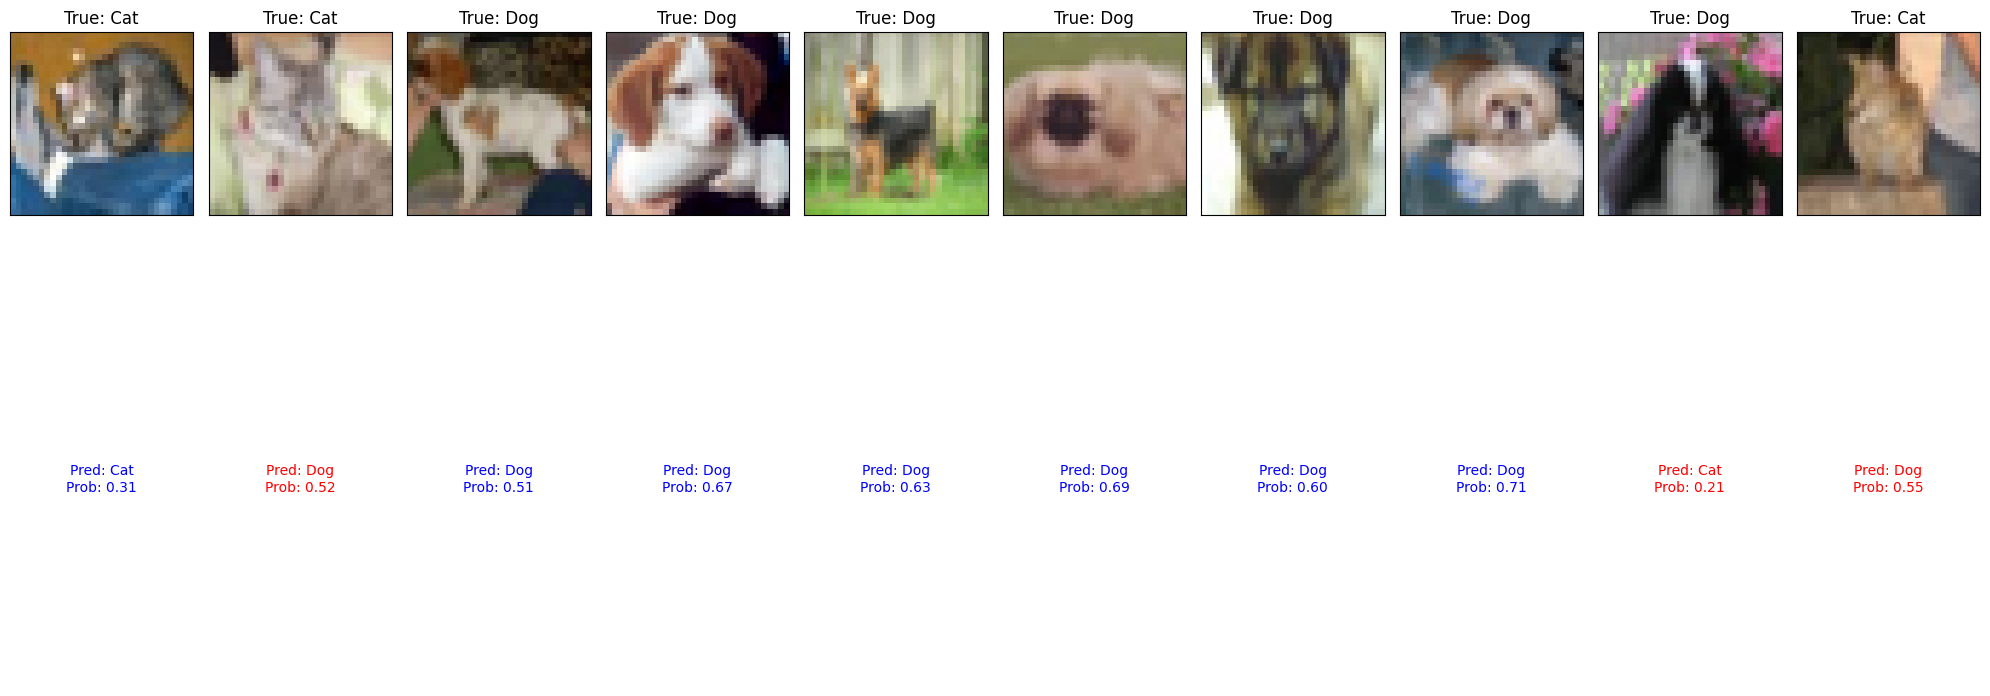

In [12]:
import matplotlib.pyplot as plt

# Đánh giá mô hình phân loại
loss, accuracy = classifier_model.evaluate(x_test_encoded, y_test_cat_dog, verbose=0)
print(f"Classifier Test Loss: {loss:.4f}")
print(f"Classifier Test Accuracy: {accuracy:.4f}")

# Hiển thị một số ảnh và dự đoán
n = 10
plt.figure(figsize=(20, 8))
for i in range(n):
    # Hiển thị ảnh gốc
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cat_dog[i])
    true_label = 'Dog' if y_test_cat_dog[i] == 1 else 'Cat'
    ax.set_title(f"True: {true_label}")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Dự đoán
    encoded_img = encoder_cat_dog.predict(x_test_cat_dog_flat[i:i+1])
    prediction_prob = classifier_model.predict(encoded_img)[0][0]
    predicted_label = 'Dog' if prediction_prob > 0.5 else 'Cat'

    ax = plt.subplot(2, n, i + 1 + n)
    plt.text(0.5, 0.5, f"Pred: {predicted_label}\nProb: {prediction_prob:.2f}",
             horizontalalignment='center', verticalalignment='center',
             fontsize=10, color='blue' if predicted_label == true_label else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()